In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/rcsb_pdb_custom_report_20260414150604.csv', header=1)
df
# Remove rows where 'Polymer EntityData' is NaN
df_cleaned = df.dropna(subset=['Sequence'])

# Remove columns that start with 'Unnamed'
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned


,Entry ID,Sequence,Auth Asym ID,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,1.0
2,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,A,1.0
4,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0
9,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0
19,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0
...,...,...,...,...
404,NaN,IVNGEEAVPGSWPWQVSLQDKTGFHFCGGSLINENWVVTAAHCGVT...,B,2.0
406,NaN,ANTPDRLQQASLPLLSNTNCKKYWGTKIKDAMICAGASGVSSCMGD...,C,3.0
408,NaN,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,4.0
410,8PTI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVGGGCRAKRNNFK...,A,1.0


In [3]:

df_cleaned = df_cleaned[df_cleaned['Sequence'].str.len() < 80]
df_cleaned = df_cleaned[df_cleaned['Sequence'].str.len() > 40]
df_cleaned.reset_index(drop=True, inplace=True)
df_cleaned

,Entry ID,Sequence,Auth Asym ID,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,1.0
1,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,A,1.0
2,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0
3,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0
4,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0
...,...,...,...,...
134,NaN,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,4.0
135,NaN,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,4.0
136,NaN,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,4.0
137,8PTI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVGGGCRAKRNNFK...,A,1.0


In [4]:
import os
import re

# 1. Setup MMseqs2 (if not already done in the current session)
if not os.path.exists("mmseqs-linux-avx2.tar.gz"):
    !wget https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
    !tar xvfz mmseqs-linux-avx2.tar.gz

os.environ['PATH'] += ":" + os.path.abspath("mmseqs/bin")

# 2. Create FASTA using PDB:Chain as the header
# This ensures clustering is performed on specific chains
with open("kunitz_chains.fasta", "w") as f:
    for idx, row in df_cleaned.iterrows():
        pdb_id = str(row['Entry ID']).strip()
        chain_id = str(row['Auth Asym ID']).strip()

        # Skip rows where IDs are missing
        if pdb_id.lower() == 'nan' or not pdb_id:
            continue

        header = f"{pdb_id}:{chain_id}"
        f.write(f">{header}\n{row['Sequence']}\n")

# 3. Run clustering (80% identity, 80% coverage)
# Centroids will represent the 'best' structure for each cluster
!mmseqs easy-cluster kunitz_chains.fasta cluster_chains_results tmp \
    --min-seq-id 0.95 \
    -c 0.95 \
    --cov-mode 0 \
    -s 7.5
# 4. Extract representative PDB:Chain pairs and save to file
representative_list = []
with open("cluster_chains_results_rep_seq.fasta", "r") as f:
    for line in f:
        if line.startswith(">"):
            # The header already contains PDB:Chain
            full_id = line.strip().replace(">", "")
            representative_list.append(full_id)

# 5. Save the final list to a file with the required pattern
with open("pdbefold_input.txt", "w") as f:
    for item in representative_list:
        f.write(f"{item}\n")

print(f"--- Process Complete ---")
print(f"Total Representatives: {len(representative_list)}")
print(f"File saved as: pdbefold_input.txt")
print("\n--- CONTENT FOR PDBEFOLD (Copy this) ---")
print("\n".join(representative_list))

--2026-05-17 10:44:40--  https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
Resolving mmseqs.com (mmseqs.com)... 158.247.200.62
Connecting to mmseqs.com (mmseqs.com)|158.247.200.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19320548 (18M) [application/octet-stream]
Saving to: ‘mmseqs-linux-avx2.tar.gz’

mmseqs-linux-avx2.t 100%[===================>]  18.42M  9.88MB/s    in 1.9s    

2026-05-17 10:44:43 (9.88 MB/s) - ‘mmseqs-linux-avx2.tar.gz’ saved [19320548/19320548]

mmseqs/
mmseqs/README.md
mmseqs/bin/
mmseqs/bin/mmseqs
mmseqs/examples/
mmseqs/examples/DB.fasta
mmseqs/examples/QUERY.fasta
mmseqs/userguide.pdf
mmseqs/util/
mmseqs/util/bash-completion.sh
mmseqs/LICENSE.md
mmseqs/matrices/
mmseqs/matrices/PAM150.out
mmseqs/matrices/PAM70.out
mmseqs/matrices/blosum62.out
mmseqs/matrices/blosum30.out
mmseqs/matrices/VTML80.out
mmseqs/matrices/VTML160.out
mmseqs/matrices/PAM30.out
mmseqs/matrices/blosum50.out
mmseqs/matrices/PAM80.out
mmseqs/matrices/PAM140.

/tmp/ipykernel_6505/3472410121.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_sizes, x="Representative", y="Cluster Size", palette="viridis")


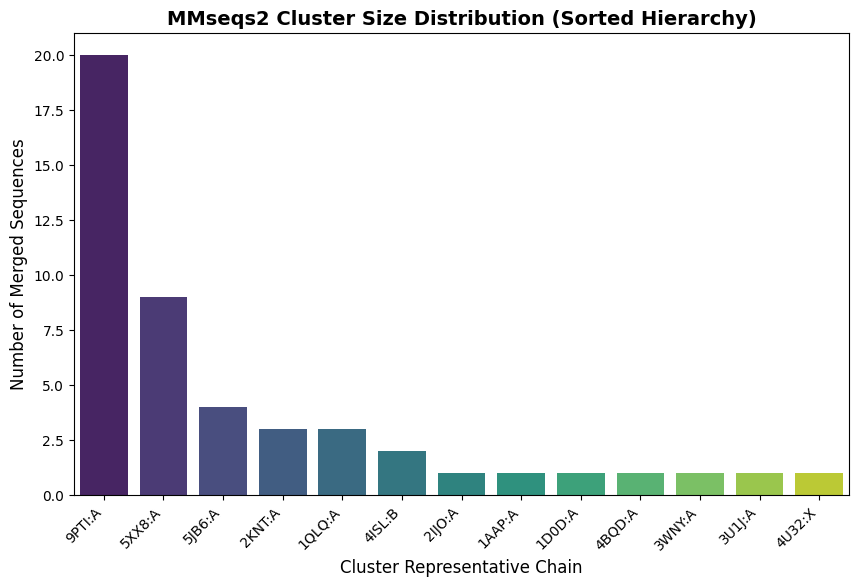

Success: Generated 'mmseqs2_cluster_size_distribution.png'


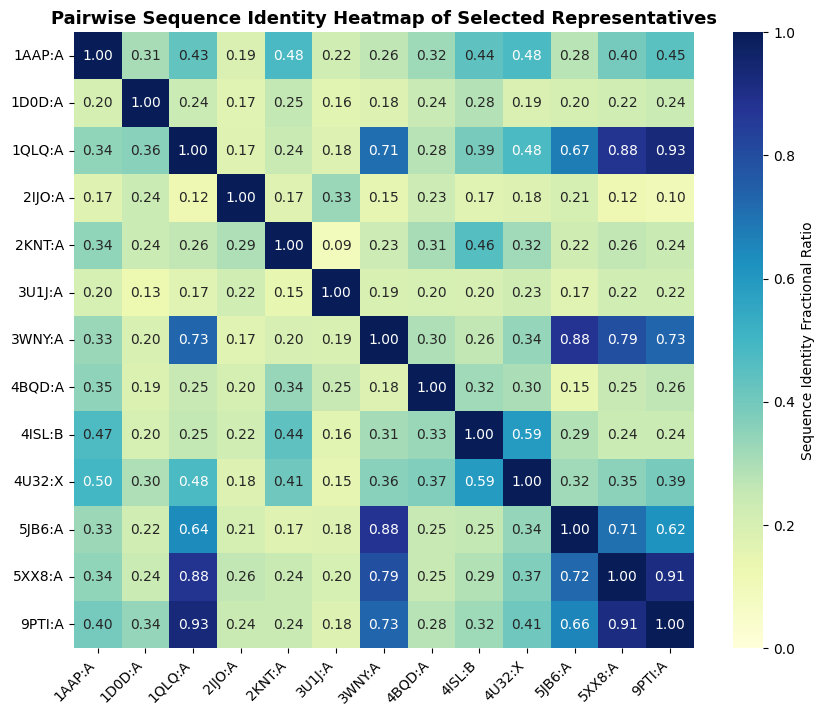

Success: Generated 'mmseqs2_representatives_heatmap.png'


In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import difflib

# ---------------------------------------------------------------------------
# PLOT 1A: Sorted Cluster Size Distribution Bar Chart
# ---------------------------------------------------------------------------
tsv_file = "cluster_chains_results_cluster.tsv"

if os.path.exists(tsv_file):
    # MMseqs2 cluster file format contains: representative_id \t member_id
    df_clusters = pd.read_csv(tsv_file, sep="\t", names=["Representative", "Member"])

    # Compute the count of members per cluster centroid
    cluster_sizes = df_clusters.groupby("Representative").size().reset_index(name="Cluster Size")

    # Sort by size in descending order for clear visual presentation
    cluster_sizes = cluster_sizes.sort_values(by="Cluster Size", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=cluster_sizes, x="Representative", y="Cluster Size", palette="viridis")

    # Clean up labels to prevent overlapping or truncation
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.title("MMseqs2 Cluster Size Distribution (Sorted Hierarchy)", fontsize=14, fontweight='bold')
    plt.xlabel("Cluster Representative Chain", fontsize=12)
    plt.ylabel("Number of Merged Sequences", fontsize=12)

    plt.savefig("mmseqs2_cluster_size_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.close()
    print("Success: Generated 'mmseqs2_cluster_size_distribution.png'")
else:
    print(f"Warning: {tsv_file} not found. Please run the clustering code block first.")

# ---------------------------------------------------------------------------
# PLOT 1B: Pairwise Sequence Identity Heatmap of Cluster Centroids
# ---------------------------------------------------------------------------
fasta_file = "cluster_chains_results_rep_seq.fasta"

if os.path.exists(fasta_file):
    # Parse the representative FASTA file
    sequences = {}
    current_id = None
    with open(fasta_file, "r") as f:
        for line in f:
            if line.startswith(">"):
                current_id = line.strip().replace(">", "").replace(".pdb", "")
                sequences[current_id] = ""
            elif current_id:
                sequences[current_id] += line.strip()

    ids = list(sequences.keys())
    n_seqs = len(ids)

    # Initialize a clean identity matrix
    identity_matrix = pd.DataFrame(index=ids, columns=ids, dtype=float)

    # Compute pairwise normalized string similarity ratios
    for i in range(n_seqs):
        for j in range(n_seqs):
            seq1 = sequences[ids[i]]
            seq2 = sequences[ids[j]]
            # difflib computes a fast, robust sequence identity percentage
            ratio = difflib.SequenceMatcher(None, seq1, seq2).ratio()
            identity_matrix.iloc[i, j] = ratio

    plt.figure(figsize=(10, 8))
    sns.heatmap(identity_matrix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
                cbar_kws={'label': 'Sequence Identity Fractional Ratio'})

    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.title("Pairwise Sequence Identity Heatmap of Selected Representatives", fontsize=13, fontweight='bold')
    plt.show()

    plt.savefig("mmseqs2_representatives_heatmap.png", dpi=300, bbox_inches='tight')

    plt.close()
    print("Success: Generated 'mmseqs2_representatives_heatmap.png'")

# FoldSeek Skipped

In [5]:
import os

# 1. Install Foldseek binary
if not os.path.exists("foldseek-linux-avx2.tar.gz"):
    !wget https://mmseqs.com/foldseek/foldseek-linux-avx2.tar.gz
    !tar xvfz foldseek-linux-avx2.tar.gz

os.environ['PATH'] += ":" + os.path.abspath("foldseek/bin")

# 2. Create directory for structures
if not os.path.exists("structures"):
    os.makedirs("structures")

# Verify installation
!foldseek

--2026-05-17 10:44:55--  https://mmseqs.com/foldseek/foldseek-linux-avx2.tar.gz
Resolving mmseqs.com (mmseqs.com)... 158.247.200.62
Connecting to mmseqs.com (mmseqs.com)|158.247.200.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11711357 (11M) [application/octet-stream]
Saving to: ‘foldseek-linux-avx2.tar.gz’

foldseek-linux-avx2 100%[===================>]  11.17M  7.50MB/s    in 1.5s    

2026-05-17 10:44:57 (7.50 MB/s) - ‘foldseek-linux-avx2.tar.gz’ saved [11711357/11711357]

foldseek/
foldseek/README.md
foldseek/bin/
foldseek/bin/foldseek
Foldseek enables fast and sensitive comparisons of large structure sets. It reaches sensitivities similar to state-of-the-art structural aligners while being at least 20,000 times faster.

Please cite:
van Kempen, M., Kim, S.S., Tumescheit, C., Mirdita, M., Lee, J., Gilchrist, C.L.M., Söding, J., and Steinegger, M. Fast and accurate protein structure search with Foldseek. Nature Biotechnology, doi:10.1038/s41587-023-01

In [6]:
!mkdir structures

mkdir: cannot create directory ‘structures’: File exists


In [7]:
import requests

def download_pdb(pdb_id):
    url = f"https://files.rcsb.org/download/{pdb_id.upper()}.pdb"
    r = requests.get(url)
    if r.status_code == 200:
        with open(f"structures/{pdb_id.upper()}.pdb", "wb") as f:
            f.write(r.content)
        return True
    return False

# Read IDs from your input file
with open("pdbefold_input.txt", "r") as f:
    ids = [line.strip() for line in f if line.strip()]

# Download each structure
print("Downloading structures...")
for entry in ids:
    pdb_id = entry.split(":")[0]
    if download_pdb(pdb_id):
        print(f"Successfully downloaded {pdb_id}")
    else:
        print(f"Failed to download {pdb_id}")

Successfully downloaded 1AAP
Successfully downloaded 1D0D
Successfully downloaded 1QLQ
Successfully downloaded 2IJO
Successfully downloaded 2KNT
Successfully downloaded 3U1J
Successfully downloaded 3WNY
Successfully downloaded 4BQD
Successfully downloaded 4ISL
Successfully downloaded 4U32
Successfully downloaded 5JB6
Successfully downloaded 5XX8
Successfully downloaded 9PTI


In [8]:
# !rm -rf structures


In [9]:
import requests
import os

def extract_specific_chain(pdb_id, chain_id, output_folder="structures"):
    """Downloads a PDB and extracts only the specified chain."""
    url = f"https://files.rcsb.org/download/{pdb_id.upper()}.pdb"
    response = requests.get(url)

    if response.status_code != 200:
        return False

    lines = response.text.splitlines()
    chain_filename = f"{output_folder}/{pdb_id.upper()}_{chain_id.upper()}.pdb"

    with open(chain_filename, "w") as f:
        for line in lines:
            if line.startswith("ATOM"):
                current_chain = line[21].strip()
                if current_chain == chain_id.upper():
                    f.write(line + "\n")
            if line.startswith("END"):
                f.write(line + "\n")
    return True

with open("pdbefold_input.txt", "r") as f:
    entries = [line.strip() for line in f if line.strip()]

print("Extracting specific chains...")
for entry in entries:
    # Pattern: '1AAL:A' -> pdb_id='1AAL', chain_id='A'
    pdb_id, chain_id = entry.split(":")
    if extract_specific_chain(pdb_id, chain_id):
        print(f"Success -> {pdb_id}:{chain_id}")
    else:
        print(f"Failed -> {pdb_id}")

Extracting specific chains...
Success -> 1AAP:A
Success -> 1D0D:A
Success -> 1QLQ:A
Success -> 2IJO:A
Success -> 2KNT:A
Success -> 3U1J:A
Success -> 3WNY:A
Success -> 4BQD:A
Success -> 4ISL:B
Success -> 4U32:X
Success -> 5JB6:A
Success -> 5XX8:A
Success -> 9PTI:A


In [10]:
!cat /content/structures/1AAP_A.pdb

ATOM      1  N   VAL A   1      25.848  28.403  44.313  1.00 42.90           N  
ATOM      2  CA  VAL A   1      25.208  29.501  43.534  1.00 38.68           C  
ATOM      3  C   VAL A   1      25.160  29.082  42.071  1.00 36.37           C  
ATOM      4  O   VAL A   1      26.018  28.302  41.621  1.00 38.11           O  
ATOM      5  CB  VAL A   1      25.969  30.799  43.858  1.00 46.05           C  
ATOM      6  CG1 VAL A   1      25.828  31.266  45.303  1.00 49.11           C  
ATOM      7  CG2 VAL A   1      27.446  30.693  43.496  1.00 43.37           C  
ATOM      8  N   ARG A   2      24.194  29.558  41.332  1.00 33.59           N  
ATOM      9  CA  ARG A   2      23.937  29.284  39.935  1.00 28.92           C  
ATOM     10  C   ARG A   2      24.149  27.907  39.361  1.00 25.66           C  
ATOM     11  O   ARG A   2      23.091  27.241  39.079  1.00 24.93           O  
ATOM     12  CB  ARG A   2      24.451  30.353  38.979  1.00 43.02           C  
ATOM     13  CG  ARG A   2  

In [11]:
import os

# Define the folder
folder = "structures"

# List all files in the folder
all_files = os.listdir(folder)

for file in all_files:
    # If the file does NOT have an underscore (e.g., '1AAL.pdb' vs '1AAL_A.pdb')
    # and it is a .pdb file, we delete the original.
    if "_" not in file and file.endswith(".pdb"):
        file_path = os.path.join(folder, file)
        os.remove(file_path)
        print(f"Removed original full PDB: {file}")

print("Workspace cleaned. Only specific chains remain.")

Removed original full PDB: 3WNY.pdb
Removed original full PDB: 2KNT.pdb
Removed original full PDB: 1D0D.pdb
Removed original full PDB: 5JB6.pdb
Removed original full PDB: 5XX8.pdb
Removed original full PDB: 2IJO.pdb
Removed original full PDB: 3U1J.pdb
Removed original full PDB: 1AAP.pdb
Removed original full PDB: 4BQD.pdb
Removed original full PDB: 4ISL.pdb
Removed original full PDB: 1QLQ.pdb
Removed original full PDB: 9PTI.pdb
Removed original full PDB: 4U32.pdb
Workspace cleaned. Only specific chains remain.


In [12]:
# Perform all-against-all 3D alignment
# --alignment-type 1: Perform 3D alignment (TM-align style)
# -a: Calculate all-against-all (if query and target are the same folder)
!foldseek easy-search structures structures results_foldseek.m8 tmp \
    --alignment-type 1 \
    --format-output "query,target,fident,alnlen,rmsd,qcov,tcov,evalue,bits,alntmscore"

easy-search structures structures results_foldseek.m8 tmp --alignment-type 1 --format-output query,target,fident,alnlen,rmsd,qcov,tcov,evalue,bits,alntmscore 

MMseqs Version:                    	718d42176d2f67d36a60866fedfb881f8d5a7ebf
TMscore threshold                  	0
TMscore threshold mode             	0
LDDT threshold                     	0
Sort by structure bit score        	1
Alignment type                     	1
Exact TMscore                      	0
Substitution matrix                	aa:3di.out,nucl:3di.out
Add backtrace                      	false
Alignment mode                     	3
Alignment mode                     	0
E-value threshold                  	10
Seq. id. threshold                 	0
Min alignment length               	0
Seq. id. mode                      	0
Alternative alignments             	0
Coverage threshold                 	0
Coverage mode                      	0
Max sequence length                	65535
Compositional bias                 	1
Compositio

In [13]:
import pandas as pd

# Define columns based on the format-output above
cols = ["Query", "Target", "Fident", "AlnLen", "RMSD", "Qcov", "Tcov", "Evalue", "Bits", "TM-score"]
df_results = pd.read_csv("results_foldseek.m8", sep="\t", names=cols)

# Filter out self-hits (e.g., 1AAL vs 1AAL)
df_filtered = df_results[df_results['Query'] != df_results['Target']]

# Display the top structural hits
print("--- Foldseek Structural Alignment Results ---")
display(df_filtered.sort_values(by="TM-score", ascending=False))

--- Foldseek Structural Alignment Results ---


,Query,Target,Fident,AlnLen,RMSD,Qcov,Tcov,Evalue,Bits,TM-score
12,5JB6_A,3WNY_A,0.910,56,0.2723,0.966,1.000,0.9715,95,1.0110
67,3WNY_A,5JB6_A,0.910,56,0.2720,1.000,0.966,0.9715,98,1.0110
57,1QLQ_A,3WNY_A,0.750,56,0.4251,0.966,1.000,0.9565,94,1.0010
68,3WNY_A,1QLQ_A,0.750,56,0.4248,1.000,0.966,0.9565,97,1.0010
1,4ISL_B,4U32_X,0.592,54,0.4598,0.900,1.000,0.9204,87,0.9986
...,...,...,...,...,...,...,...,...,...,...
98,1AAP_A,1D0D_A,0.106,66,2.7600,0.982,1.000,0.5593,57,0.6555
109,4BQD_A,1D0D_A,0.151,66,2.8100,0.705,1.000,0.4976,45,0.6555
53,1D0D_A,4BQD_A,0.151,66,2.8100,1.000,0.705,0.4976,54,0.6555
50,1D0D_A,1AAP_A,0.104,67,2.8010,1.000,1.000,0.5653,55,0.6512


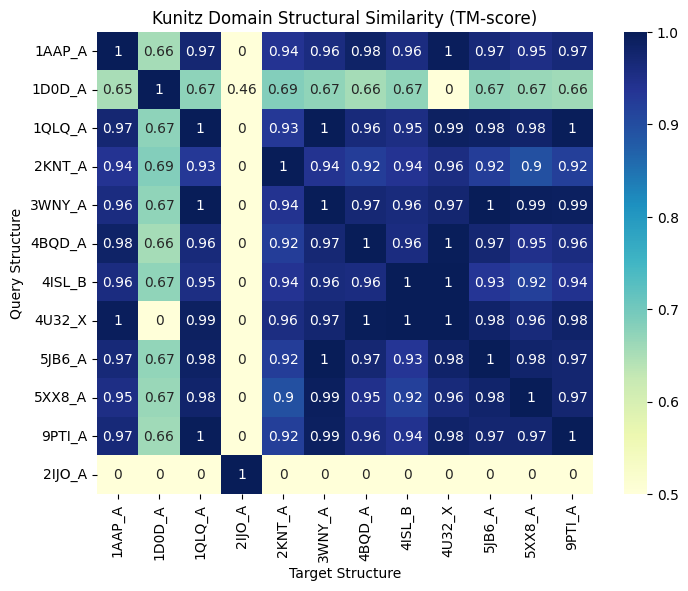

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data for the matrix
# We use TM-score as it is the most reliable metric for the 'fold'
plot_df = df_filtered[['Query', 'Target', 'TM-score']].copy()

# 2. Pivot the dataframe into a square matrix
matrix = plot_df.pivot(index='Query', columns='Target', values='TM-score')

# 3. Fill the diagonal (self-hits) with 1.0 (perfect match)
# and missing hits with 0.0 (non-significant)
import numpy as np
for col in matrix.columns:
    matrix.loc[col, col] = 1.0
matrix = matrix.fillna(0.0)

# 4. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='YlGnBu', vmin=0.5, vmax=1.0)
plt.title('Kunitz Domain Structural Similarity (TM-score)')
plt.xlabel('Target Structure')
plt.ylabel('Query Structure')
plt.show()

# UsAlign

In [15]:
import os

# 1. Clean up any failed downloads
!rm -rf USalign us_align_source

# 2. Clone the repository
!git clone https://github.com/pylelab/USalign.git us_align_source

# 3. Compile the binary (this takes about 30 seconds)
%cd us_align_source
!make
%cd ..

# 4. Copy the binary to your main folder and make it executable
!cp us_align_source/USalign ./USalign
!chmod +x USalign

# 5. Verify it's alive
!./USalign -h | head -n 5

Cloning into 'us_align_source'...
remote: Enumerating objects: 1565, done.
remote: Counting objects: 100% (430/430), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 1565 (delta 395), reused 383 (delta 359), pack-reused 1135 (from 2)
Receiving objects: 100% (1565/1565), 809.16 KiB | 2.86 MiB/s, done.
Resolving deltas: 100% (1117/1117), done.
/content/us_align_source
g++ -O3 -ffast-math qTMclust.cpp -o qTMclust 
g++ -O3 -ffast-math USalign.cpp -o USalign 
g++ -O3 -ffast-math TMalign.cpp -o TMalign 
g++ -O3 -ffast-math TMscore.cpp -o TMscore 
g++ -O3 -ffast-math MMalign.cpp -o MMalign 
g++ -O3 -ffast-math se.cpp -o se 
g++ -O3 -ffast-math pdb2xyz.cpp -o pdb2xyz 
g++ -O3 -ffast-math xyz_sfetch.cpp -o xyz_sfetch 
g++ -O3 -ffast-math pdb2fasta.cpp -o pdb2fasta 
g++ -O3 -ffast-math biounitasym.cpp -o biounitasym 
g++ -O3 -ffast-math pdb2ss.cpp -o pdb2ss 
g++ -O3 -ffast-math NWalign.cpp -o NWalign 
g++ -O3 -ffast-math HwRMSD.cpp -o HwRMSD 
g++ -O3 -ffast-math cif2pdb.cpp -

In [39]:
import os
import subprocess

def build_star_alignment(msa_records, reference_pdb):
    """Merges variable-length pairwise alignments into a strict equal-length MSA."""
    # 1. Extract the raw, ungapped reference sequence
    sample_ref = next(iter(msa_records.values()))[0]
    ref_ungapped = sample_ref.replace("-", "").replace(".", "")

    # 2. Track maximum insertions between every reference character
    max_insertions = [0] * (len(ref_ungapped) + 1)
    target_data = {}

    for tgt, (r_seq, t_seq) in msa_records.items():
        aligned_chars = []
        insertions = [[] for _ in range(len(ref_ungapped) + 1)]

        ref_idx = 0
        curr_insertion = []

        for r, t in zip(r_seq, t_seq):
            if r == "-":
                curr_insertion.append(t) # Target inserted something here
            else:
                # We hit a reference character
                insertions[ref_idx] = curr_insertion
                if len(curr_insertion) > max_insertions[ref_idx]:
                    max_insertions[ref_idx] = len(curr_insertion)

                aligned_chars.append(t) # The character (or gap) aligned to the ref
                ref_idx += 1
                curr_insertion = []

        # Handle tail insertions after the last reference character
        insertions[ref_idx] = curr_insertion
        if len(curr_insertion) > max_insertions[ref_idx]:
            max_insertions[ref_idx] = len(curr_insertion)

        target_data[tgt] = {"aligned": aligned_chars, "insertions": insertions}

    # 3. Build the final equal-length MSA
    final_msa = {reference_pdb: ""}
    for tgt in msa_records: final_msa[tgt] = ""

    for i in range(len(ref_ungapped) + 1):
        max_ins = max_insertions[i]
        final_msa[reference_pdb] += "-" * max_ins # Pad the master reference

        for tgt in msa_records:
            ins_chars = "".join(target_data[tgt]["insertions"][i])
            padding = "-" * (max_ins - len(ins_chars))
            final_msa[tgt] += ins_chars + padding # Pad targets that didn't have this insertion

        if i < len(ref_ungapped):
            final_msa[reference_pdb] += ref_ungapped[i]
            for tgt in msa_records:
                final_msa[tgt] += target_data[tgt]["aligned"][i]

    return final_msa

# --- Execution ---
structure_dir = "structures"
pdb_files = [f for f in os.listdir(structure_dir) if f.endswith(".pdb")]
pdb_files.sort()

reference_pdb = pdb_files[0]
targets = pdb_files[1:]

msa_records = {}
print(f"Running pairwise alignments to Reference: {reference_pdb}...")

for tgt in targets:
    file1 = os.path.join(structure_dir, tgt)
    file2 = os.path.join(structure_dir, reference_pdb)
    cmd = f"./USalign {file1} {file2} "


    try:
        output = subprocess.check_output(cmd, shell=True, text=True)
        tm_match = re.search(r'TM-score\s*=\s*([0-9.]+)', output)
        tm_score = float(tm_match.group(1)) if tm_match else 0.0 ### IMPROVE
        print(tm_score)

        lines = output.splitlines()
        target_seq, ref_seq = "", ""

        for i, line in enumerate(lines):
            if 'denotes residue pairs' in line:
                target_seq = lines[i+1].strip()
                ref_seq = lines[i+3].strip()
                break

        len_ratio = len(target_seq.replace("-", "")) / len(ref_seq.replace("-", "")) ### IMPROVE
        # msa_records[tgt] = (ref_seq, target_seq)
        cys_count = target_seq.upper().count('C')
        print('>>>>>>>>' , cys_count)
        if target_seq and tm_score > 0.5 and (0.05 < len_ratio < 1.6) and cys_count >= 6:
            msa_records[tgt] = (ref_seq, target_seq)
        else:
            print(f"Skipping {tgt}: TM={tm_score:.2f}, LenRatio={len_ratio:.2f}, cys: {cys_count}")

    except Exception:
        print(f"Failed alignment for {tgt}")

print("Merging into a uniform Star Alignment...")
final_msa = build_star_alignment(msa_records, reference_pdb)

fasta_out = "kunitz_structural_msa_fixed.fasta"
with open(fasta_out, "w") as f:
    for name, seq in final_msa.items():
        # Verify length consistency
        print(f"{name} Length: {len(seq)}")
        f.write(f">{name.replace('.pdb', '')}\n{seq}\n")

print(f"\nFixed MSA successfully saved to {fasta_out}!")

Running pairwise alignments to Reference: 1AAP_A.pdb...
0.55167
>>>>>>>> 6
0.90397
>>>>>>>> 6
0.17396
>>>>>>>> 0
Skipping 2IJO_A.pdb: TM=0.17, LenRatio=0.73, cys: 0
0.85916
>>>>>>>> 6
0.16688
>>>>>>>> 0
Skipping 3U1J_A.pdb: TM=0.17, LenRatio=0.36, cys: 0
0.91518
>>>>>>>> 2
Skipping 3WNY_A.pdb: TM=0.92, LenRatio=1.00, cys: 2
0.69284
>>>>>>>> 6
0.85782
>>>>>>>> 6
0.94614
>>>>>>>> 6
0.89731
>>>>>>>> 2
Skipping 5JB6_A.pdb: TM=0.90, LenRatio=1.04, cys: 2
0.87774
>>>>>>>> 2
Skipping 5XX8_A.pdb: TM=0.88, LenRatio=1.04, cys: 2
0.89595
>>>>>>>> 6
Merging into a uniform Star Alignment...
1AAP_A.pdb Length: 90
1D0D_A.pdb Length: 90
1QLQ_A.pdb Length: 90
2KNT_A.pdb Length: 90
4BQD_A.pdb Length: 90
4ISL_B.pdb Length: 90
4U32_X.pdb Length: 90
9PTI_A.pdb Length: 90

Fixed MSA successfully saved to kunitz_structural_msa_fixed.fasta!


In [40]:
!cat $fasta_out

>1AAP_A
--------------------VREV-CSEQA--ET------GPCRAMISRWYFDVTEGKCAPFFYGG--CGGNRNNFDTEEYCMAVCG---
>1D0D_A
--------------------Y-NRLC-IKPRDWIDECDSN---EGGERAYFRNG-KGGCDSFWICPEDHTGAD-YYSSYRDCFNACI---
>1QLQ_A
--------------------RPDF-CLEPP--YA------GACRARIIRYFYNAKAGLCQTFVYGG--CRAKRNNFKSAEDCLRTCGGA-
>2KNT_A
--------------------ETDI-CKLPK--DE------GTCRDFILKWYYDPNTKSCARFWYGG--CGGNENKFGSQKECEKVCAPV-
>4BQD_A
SEEDEEHTIITDTELPPLKLMHSF-CAFKA--DD------GPCKAIMKRFFFNIFTRQCEEFIYGG--CEGNQNRFESLEECKKMCTRD-
>4ISL_B
--------------------QTEDYCLASN--KV------GRCRGSFPRWYYDPTEQICKSFVYGG--CLGNKNNYLREEECILACRGVQ
>4U32_X
----------------------HDFCLVSK--VV------GRCRASMPRWWYNVTDGSCQLFVYGG--CDGNSNNYLTKEECLKKC----
>9PTI_A
--------------------RPDF-CLEPP--YT------GPCKARIIRYFYNAKAGLCQTFVYGG--CRAKRNNFKSAEDC-RTCGGA-


Computing All-against-All structural cross-matrix via US-align...


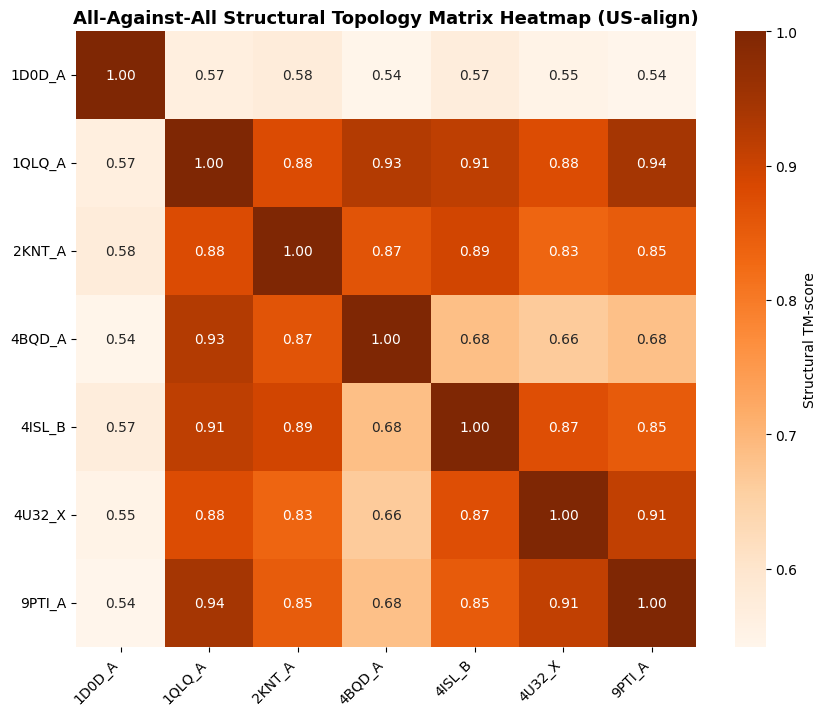

Success: Generated 'usalign_pairwise_structural_heatmap.png'


In [41]:
import os
import re
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all structures that successfully passed your biological and structural quality controls
filtered_structures = list(msa_records.keys())
filtered_structures.sort()

# Initialize an empty coordinate matrix frame
matrix_data = {s: {s2: 1.0 for s2 in filtered_structures} for s in filtered_structures}

print("Computing All-against-All structural cross-matrix via US-align...")
for i, struct1 in enumerate(filtered_structures):
    for j, struct2 in enumerate(filtered_structures):
        if i >= j:  # Leverage symmetry properties to save processing cycles
            continue

        file1 = os.path.join(structure_dir, struct1)
        file2 = os.path.join(structure_dir, struct2)
        cmd = f"./USalign {file1} {file2} -fast"

        try:
            output = subprocess.check_output(cmd, shell=True, text=True)
            tm_match = re.search(r'TM-score\s*=\s*([0-9.]+)', output)
            score = float(tm_match.group(1)) if tm_match else 0.0

            # Map values symmetrically
            matrix_data[struct1][struct2] = score
            matrix_data[struct2][struct1] = score
        except Exception:
            matrix_data[struct1][struct2] = 0.0
            matrix_data[struct2][struct1] = 0.0

# Build clean labels for your heatmap by stripping file extensions
df_matrix = pd.DataFrame(matrix_data)
df_matrix.index = [x.replace(".pdb", "") for x in df_matrix.index]
df_matrix.columns = [x.replace(".pdb", "") for x in df_matrix.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df_matrix, annot=True, fmt=".2f", cmap="Oranges", cbar_kws={'label': 'Structural TM-score'})

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("All-Against-All Structural Topology Matrix Heatmap (US-align)", fontsize=13, fontweight='bold')

plt.savefig("usalign_pairwise_structural_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

plt.close()
print("Success: Generated 'usalign_pairwise_structural_heatmap.png'")

In [42]:
# Install HMMER if you haven't already
!apt-get install hmmer

!hmmbuild kunitz_profile.hmm kunitz_structural_msa_fixed.fasta

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
hmmer is already the newest version (3.3.2+dfsg-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
# hmmbuild :: profile HMM construction from multiple sequence alignments
# HMMER 3.3.2 (Nov 2020); http://hmmer.org/
# Copyright (C) 2020 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# input alignment file:             kunitz_structural_msa_fixed.fasta
# output HMM file:                  kunitz_profile.hmm
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# idx name                  nseq  alen  mlen eff_nseq re/pos description
#---- -------------------- ----- ----- ----- -------- ------ -----------
1     kunitz_structural_msa_fixed     8    90    58     1.70  0.961 

# CPU time: 0.03u 0.00s 00:00:00.03 Elapsed: 00:00:00.03


In [43]:
!hmmsearch --max --noali --tblout hmm_positives_results.tbl -E 10000 -Z 20794 kunitz_profile.hmm pos_non_human_bpti.fasta

# hmmsearch :: search profile(s) against a sequence database
# HMMER 3.3.2 (Nov 2020); http://hmmer.org/
# Copyright (C) 2020 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# query HMM file:                  kunitz_profile.hmm
# target sequence database:        pos_non_human_bpti.fasta
# per-seq hits tabular output:     hmm_positives_results.tbl
# show alignments in output:       no
# sequence reporting threshold:    E-value <= 10000
# Max sensitivity mode:            on [all heuristic filters off]
# sequence search space set to:    20794
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

Query:       kunitz_structural_msa_fixed  [M=58]
Scores for complete sequences (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Sequence                  Descriptio

In [44]:
!hmmsearch --max --noali --tblout hmm_negatives_results.tbl -E 10000 -Z 20794 kunitz_profile.hmm neg_human_non_bpti.fasta

Streaming output truncated to the last 5000 lines.

>> sp|Q9NZ53|PDXL2_HUMAN  Podocalyxin-like protein 2 OS=Homo sapiens OX=9606 GN=PODXL2 PE=1 SV=1
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|Q14767|LTBP2_HUMAN  Latent-transforming growth factor beta-binding protein 2 OS=Homo sapiens OX=9606 GN=LTBP2 PE=1
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|Q9UHD4|CIDEB_HUMAN  Lipid transferase CIDEB OS=Homo sapiens OX=9606 GN=CIDEB PE=1 SV=2
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|O60404|O10H3_HUMAN  Olfactory receptor 10H3 OS=Homo sapiens OX=9606 GN=OR10H3 PE=2 SV=1
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|P57053|H2BFS_HUMAN  Histone H2B type F-S OS=Homo sapiens OX=9606 GN=H2BC12L PE=1 SV=2
   [No individual domains that satisfy reporting thresholds (although complete 

In [45]:
# Format positives
!grep -v '^#' hmm_positives_results.tbl | awk '{print $1"\t"$8"\t1"}' > positive.match

# Format negatives (These are False Positives!)
!grep -v '^#' hmm_negatives_results.tbl | awk '{print $1"\t"$8"\t1"}' > negative.match

In [46]:
!head positive.match

sp|Q868Z9|PPN_DROME	6.5e-16	1
sp|O76840|PPN1_CAEEL	1.2e-17	1
sp|A0A6P8HC43|ATPI1_ACTTE	4.9e-22	1
sp|Q28864|TFPI1_MACMU	5.7e-25	1
sp|Q02445|TFPI1_RAT	1.7e-22	1
sp|O54819|TFPI1_MOUSE	7.7e-23	1
sp|P19761|TFPI1_RABIT	1.4e-22	1
sp|P84875|PCPI_SABMA	1.2e-19	1
sp|P83606|BMTI6_RHIMP	2.3e-19	1
sp|Q03610|YN81_CAEEL	1.2e-14	1


In [47]:
# 1. Get ALL IDs from the original negative file
!grep ">" neg_human_non_bpti.fasta | awk '{print $1}' | tr -d ">" | sort > all_neg_ids.txt

# 2. Get IDs that the HMM actually hit (False Positives)
!awk '{print $1}' negative.match | sort > hit_neg_ids.txt

# 3. Use 'comm' to find IDs in 'all' but NOT in 'hits' (True Negatives)
!comm -23 all_neg_ids.txt hit_neg_ids.txt | awk '{print $1"\t10000\t0"}' > negative.nonmatch

In [48]:
# !cat positive.match negative.match negative.nonmatch | sort -R > final_eval_data.txt

In [49]:
!tail final_eval_data.txt

tail: cannot open 'final_eval_data.txt' for reading: No such file or directory


In [50]:
# --- Corrected 2-Fold Cross-Validation Script ---

print("Shuffling datasets...")

# 1. SHUFFLE THE POSITIVES (Your excellent catch!)
!cat positive.match | sort -R > positive_shuffled.match

# 2. Merge and SHUFFLE the Negatives
!cat negative.match negative.nonmatch | sort -R > negative_total.match

# 3. Get total counts to calculate the split point
pos_count = !wc -l < positive_shuffled.match
neg_count = !wc -l < negative_total.match

pos_half = int(int(pos_count[0]) / 2)
neg_half = int(int(neg_count[0]) / 2)

print(f"Total Positives: {pos_count[0]} | Splitting into groups of {pos_half}")
print(f"Total Negatives: {neg_count[0]} | Splitting into groups of {neg_half}")

# 4. Create Fold 1 (Set 1) using the SHUFFLED files
!head -n {pos_half} positive_shuffled.match > kunitz_set_1.txt
!head -n {neg_half} negative_total.match >> kunitz_set_1.txt

# 5. Create Fold 2 (Set 2) using the SHUFFLED files
!tail -n +{pos_half + 1} positive_shuffled.match > kunitz_set_2.txt
!tail -n +{neg_half + 1} negative_total.match >> kunitz_set_2.txt

# 6. Verify the files
!wc kunitz_set_1.txt kunitz_set_2.txt
print("\nSuccess! Both folds now have perfectly randomized data.")

Shuffling datasets...
Total Positives: 380 | Splitting into groups of 190
Total Negatives: 20414 | Splitting into groups of 10207
 10397  31191 319451 kunitz_set_1.txt
 10397  31191 319388 kunitz_set_2.txt
 20794  62382 638839 total

Success! Both folds now have perfectly randomized data.


In [ ]:
# 1. Search (The No-Cheat way - keeping the math honest)
!hmmsearch --max --noali --tblout hmm_positives_results.tbl -E 10000 -Z 20794 kunitz_profile.hmm pos_non_human_bpti.fasta
!hmmsearch --max --noali --tblout hmm_negatives_results.tbl -E 10000 -Z 20794 kunitz_profile.hmm neg_human_non_bpti.fasta

# 2. Format positives (Ground Truth = 1)
!grep -v '^#' hmm_positives_results.tbl | awk '{print $1"\t"$8"\t1"}' > positive.match

# 3. Format negatives (THE FIX: Ground Truth = 0)
!grep -v '^#' hmm_negatives_results.tbl | awk '{print $1"\t"$8"\t0"}' > negative.match

# 4. Find True Negatives (Ground Truth = 0, fake E-value = 100)
!grep ">" neg_human_non_bpti.fasta | awk '{print $1}' | tr -d ">" | sort > all_neg_ids.txt
!awk '{print $1}' negative.match | sort > hit_neg_ids.txt
!comm -23 all_neg_ids.txt hit_neg_ids.txt | awk '{print $1"\t100\t0"}' > negative.nonmatch

Streaming output truncated to the last 5000 lines.

>> sp|Q9Y6K0|CEPT1_HUMAN  Choline/ethanolaminephosphotransferase 1 OS=Homo sapiens OX=9606 GN=CEPT1 PE=1 SV=1
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|Q0IIM8|TBC8B_HUMAN  TBC1 domain family member 8B OS=Homo sapiens OX=9606 GN=TBC1D8B PE=1 SV=2
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|O00186|STXB3_HUMAN  Syntaxin-binding protein 3 OS=Homo sapiens OX=9606 GN=STXBP3 PE=1 SV=2
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|Q7Z2W4|ZCCHV_HUMAN  Zinc finger CCCH-type antiviral protein 1 OS=Homo sapiens OX=9606 GN=ZC3HAV1 PE=1 SV=3
   [No individual domains that satisfy reporting thresholds (although complete target did)]

>> sp|Q96RK4|BBS4_HUMAN  BBSome complex member BBS4 OS=Homo sapiens OX=9606 GN=BBS4 PE=1 SV=2
   [No individual domains that satisfy reporting thresholds (a

In [56]:
# --- Corrected 2-Fold Cross-Validation Script ---

print("Shuffling datasets...")

# 1. SHUFFLE THE POSITIVES (Crucial for balanced folds)
!cat positive.match | sort -R > positive_shuffled.match

# 2. Merge and SHUFFLE the Negatives
!cat negative.match negative.nonmatch | sort -R > negative_total.match

# 3. Calculate splits
pos_count = !wc -l < positive_shuffled.match
neg_count = !wc -l < negative_total.match

pos_half = int(int(pos_count[0]) / 2)
neg_half = int(int(neg_count[0]) / 2)

# 4. Create Folds
!head -n {pos_half} positive_shuffled.match > kunitz_set_1.txt
!head -n {neg_half} negative_total.match >> kunitz_set_1.txt

!tail -n +{pos_half + 1} positive_shuffled.match > kunitz_set_2.txt
!tail -n +{neg_half + 1} negative_total.match >> kunitz_set_2.txt

print(f"Success! Fold 1 and 2 ready.")

Shuffling datasets...
Success! Fold 1 and 2 ready.


In [57]:
import matplotlib.pyplot as plt

mcc_fold1 = []
mcc_fold2 = []
threshold_labels = []

print("Running Evaluation for Fold 1...")
for i in range(1, 16):
    # Calculate threshold string
    threshold = f"1e{(i-4)*-1}"
    threshold_labels.append(threshold)

    # Run the script and capture the output in Colab
    raw_out = !python3 performance.py kunitz_set_1.txt {threshold}

    # Get the last printed line
    out_str = raw_out[-1]
    print(out_str) # Print it so you can still see the progress

    # THE FIX: Split by "MCC: ", take the right side, then split by "," and take the left side!
    mcc_string = out_str.split("MCC: ")[1].split(",")[0].strip()
    mcc_fold1.append(float(mcc_string))


print("\nRunning Evaluation for Fold 2...")
for i in range(1, 16):
    threshold = f"1e{(i-4)*-1}"

    raw_out = !python3 performance.py kunitz_set_2.txt {threshold}
    out_str = raw_out[-1]
    print(out_str)

    # Parse the exact same way
    mcc_string = out_str.split("MCC: ")[1].split(",")[0].strip()
    mcc_fold2.append(float(mcc_string))


Running Evaluation for Fold 1...
TH: 1000.0	ACC: 0.4975	MCC: 0.1309, TP:190.0, TN:4983.0, FP:5224.0, FN:0.0
TH: 100.0	ACC: 0.5150	MCC: 0.1355, TP:190.0, TN:5164.0, FP:5043.0, FN:0.0
TH: 10.0	ACC: 0.9999	MCC: 0.9973, TP:190.0, TN:10206.0, FP:1.0, FN:0.0
TH: 1.0	ACC: 1.0000	MCC: 1.0000, TP:190.0, TN:10207.0, FP:0.0, FN:0.0
TH: 0.1	ACC: 0.9998	MCC: 0.9946, TP:188.0, TN:10207.0, FP:0.0, FN:2.0
TH: 0.01	ACC: 0.9997	MCC: 0.9919, TP:187.0, TN:10207.0, FP:0.0, FN:3.0
TH: 0.001	ACC: 0.9997	MCC: 0.9919, TP:187.0, TN:10207.0, FP:0.0, FN:3.0
TH: 0.0001	ACC: 0.9997	MCC: 0.9919, TP:187.0, TN:10207.0, FP:0.0, FN:3.0
TH: 1e-05	ACC: 0.9996	MCC: 0.9892, TP:186.0, TN:10207.0, FP:0.0, FN:4.0
TH: 1e-06	ACC: 0.9995	MCC: 0.9865, TP:185.0, TN:10207.0, FP:0.0, FN:5.0
TH: 1e-07	ACC: 0.9995	MCC: 0.9865, TP:185.0, TN:10207.0, FP:0.0, FN:5.0
TH: 1e-08	ACC: 0.9995	MCC: 0.9865, TP:185.0, TN:10207.0, FP:0.0, FN:5.0
TH: 1e-09	ACC: 0.9993	MCC: 0.9811, TP:183.0, TN:10207.0, FP:0.0, FN:7.0
TH: 1e-10	ACC: 0.9993	MCC: 0.98

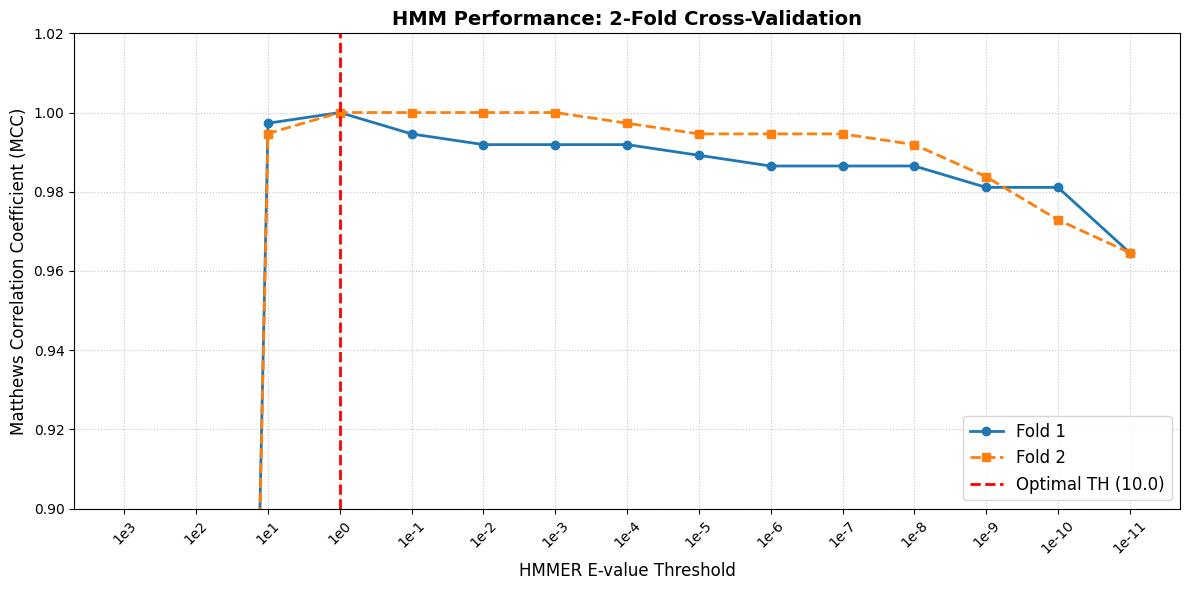

In [58]:

# ---------------------------------------------------------
# Plotting the Results
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot both lists
plt.plot(range(1, 16), mcc_fold1, marker='o', linestyle='-', linewidth=2, label='Fold 1')
plt.plot(range(1, 16), mcc_fold2, marker='s', linestyle='--', linewidth=2, label='Fold 2')

plt.axvline(x=4, color='red', linestyle='--', linewidth=2, label='Optimal TH (10.0)')
# Set Y-axis between 0.8 and 1.0 (added 1.02 so the top dots aren't cut off)
plt.ylim(0.9, 1.02)

# Format the X-axis
plt.xticks(range(1, 16), threshold_labels, rotation=45)

# Add Labels and Title
plt.xlabel('HMMER E-value Threshold', fontsize=12)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.title('HMM Performance: 2-Fold Cross-Validation', fontsize=14, fontweight='bold')

plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Show the plot!
plt.show()